<a href="https://colab.research.google.com/github/fzunigaGH/Proyectos/blob/main/Prediccion_precio_de_ticket_aereo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Machine Learning

#1.- Descripción del problema

##1.1.- Descripción del **problema**

Se desea ofrecer a los clientes de una agencia de viajes, una
herramienta que les permita obtener estimaciones precisas del precio de los boletos de
avión para su próximo viaje, en función de múltiples factores, como la aerolínea, el destino, la temporada, la
clase de servicio y la anticipación de la reserva.

El objetivo propuesto es desarrollar un modelo de Machine Learning que pueda predecir el precio
de un boleto de avión en función de estas variables.

##1.2.- Objetivos

1.2.1.- Analizar de forma exploratoria los atributos.

1.2.2.- Proponer un modelo predictivo que prediga el precio de un ticket aéreo.

1.2.3.- Generar al tres modelos predictivos que permitan determinar el precio del ticket aéreo.

1.2.4.- Comparar métricas de modelos generados y determinar el mejor modelo que prediga el precio del ticket aéreo.


##1.3.- Análisis del problema

La información disponible para resolver el problema está contenida en dos DataFrame (Business.xlsx y Economic.xlsx). Estos dataframe contienen datos relacionados  con distintos atributos.

Al analizar la descripción del problema se identifica que el problema a resolver corresponde a un problema de regresión. Lo anterior dado que la variable a predecir corresponde a una variable continua (**precio**).

##1.4.- Metodología, tareas

La metodología utilizada está basada en CRISP DM, abordando en primera instancia actividades relacionadas con el entendimiento del negocio y los datos que permitirán elaborar los modelos de Machine Learning que serán evaluados para su posterior despliegue en producción.

Las tareas a realizar se detallan a continuación:


* carga de set de datos y análisis de calidad de la información contenida en ellos.
* Análisis Exploratorio (EDA) y transformación de datos.
* Codificación y escalado de variables.
* Identificación, análisis y manipulación de outliers según clase.
* Análisis de Correlaciones.
* Entrenamiento y optimización de modelos de ML.
* Conclusión final y recomendaciones.

#2.- Antecedentes y requerimientos previos

##2.1.- Diccionario de Datos

* **Date**: Fecha del vuelo.
* **Airline**: Nombre de la aerolínea.
* **ch_code**: Código IATA de la aerolínea, compuesto por 2 caracteres.
* **num_code**: número del vuelo. Identificador numérico del vuelo.
* **dep_time**: Hora de salida del vuelo.
* **from**: Ciudad de origen. Lugar de partida del vuelo.
* **time_taken**: Duración del viaje.
* **stop**: Escalas. Indica si el vuelo es directo o el número de escalas que realiza.
* **arr_time**: hora de llegada a destino.
* **to**: Ciudad de destino. Lugar de llegada del vuelo.
* **price**: Precio del ticket. Valor monetario del pasaje.

##2.2.- Librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from scipy.stats import pearsonr, chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import ElasticNet, ElasticNetCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc,roc_auc_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor

from imblearn.over_sampling import SMOTE
import graphviz

from sklearn.metrics import f1_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

##2.3.- Funciones

In [ ]:
def calidad_datos(datos):
    tipos = pd.DataFrame(datos.dtypes, columns = ['tipo'])
    nan_prop = pd.DataFrame(datos.isna().sum() / datos.shape[0]*100, columns = ["%_nan"])
    ceros_prop = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0] / datos.shape[0]*100 for col in datos.columns], \
                                columns = ["%_ceros"], index = datos.columns)
    resumen = datos.describe(include = 'all').T
    resumen['range'] = resumen['max'] - resumen['min']
    resumen['lim_inf'] = resumen['25%'] - (resumen['75%'] - resumen['25%']) * 1.5
    resumen['lim_sup'] = resumen['75%'] + (resumen['75%'] - resumen['25%']) * 1.5

    resumen['%_atipicos'] = datos.apply(lambda x:
                                        sum(
                                            np.where((x < resumen['lim_inf'][x.name]) | (x > resumen['lim_sup'][x.name]), 1, 0)
                                        ) / datos.shape[0] * 100
                                        if x.name in resumen['lim_inf'].dropna().index else 0)

    return pd.concat([tipos, nan_prop, ceros_prop, resumen], axis = 1).sort_values('tipo')



def remove_outliers(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  return  df_desafio

def identifica_outliers(df, column):# función identifica_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
  sns.boxplot(df[column])
  plt.title(f"Boxplot de {column}")
  plt.show()
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_SO = df[(df[column]< lower_bound) | (df[column] > upper_bound)]
  #print(f"\n\nA continuación se presentan los registros outliers\n")
  #sns.histplot(df_SO[column], bins= 20
  return df_SO

def df_sin_outliers(df, column): # función que retorna un DataFrame sin elementos outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_desafio = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
  return df_desafio

def remove_outliers_upper(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_desafio = df[df[column] <= upper_bound]
  return df_desafio

def remove_outliers_lower(df, column):# función remove_outliers. Recibe como parámetros: el DataFrame y la columna del dataframe que se requiere analizar
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_desafio = df[df[column] >= lower_bound]
  return df_desafio

def correlacion(datos, target, dicotomic = False):
  numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()
  for feature in numeric_features:
    dfi = datos.loc[:, [feature, target]].dropna()
    corr, _ = pearsonr(dfi[feature], dfi[target])
    if isinstance(corr, np.ndarray):
      print(f"Correlación de Pearson entre {feature} y {target}: {corr[0]:.2f}")
    else:
      print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")

  correlation_matrix_numeric = datos[numeric_features].corr()

  plt.rcParams.update({'font.size': 12})
  plt.figure(figsize = (4,8))
  sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:], cmap = 'Reds', annot = True)

  categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
  if dicotomic == True:
    for feature in categorical_features:
      target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
      chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
      if p < 0.05:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
      else:
        print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")
  return numeric_features, categorical_features


In [ ]:
def find_best_model_regression(X, y):
    # Definir los hiperparámetros a ajustar para cada algoritmo
    Elastic_params = {
      'alpha': [0.01, 0.1, 1.0, 10.0],
      'l1_ratio': [0.2, 0.5, 0.8]
      }

    tree_params = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
    }

    RF_params = {
      'n_estimators': [100,200],
      'max_depth': [10,20],
      'min_samples_split': [2,5],
      'max_features': ['sqrt', 'log2']
    }

    # Definir los modelos

    elastic = ElasticNet()
    arbol = DecisionTreeRegressor()
    RF = RandomForestRegressor()

    # Realizar la búsqueda de hiperparámetros utilizando validación cruzada
    models = [elastic, arbol, RF]
    params = [Elastic_params, tree_params, RF_params]
    best_model = None
    best_params = None
    best_score = float('-inf')

    models_save = []

    for model, param_grid in zip(models, params):
        grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(X, y)

        if grid_search.best_score_ > best_score:
            best_score = grid_search.best_score_
            best_model = model
            best_params = grid_search.best_params_
        print("Best Model: ", grid_search.best_estimator_)
        print("Best params: ", grid_search.best_params_)
        print("Ajuste: ", -grid_search.best_score_)
        print('-'*100)
        models_save.append(grid_search.best_estimator_)

    return best_model, best_params, models_save

In [ ]:
def categorize_dep_time(time_obj):
    hour = time_obj.hour
    if 0 <= hour <= 2:
        return 'Bloque 1'
    elif 3 <= hour <= 5:
        return 'Bloque 2'
    elif 6 <= hour <= 8:
        return 'Bloque 3'
    elif 9 <= hour <= 11:
        return 'Bloque 4'
    elif 12 <= hour <= 14:
        return 'Bloque 5'
    elif 15 <= hour <= 17:
        return 'Bloque 6'
    elif 18 <= hour <= 20:
        return 'Bloque 7'
    elif 21 <= hour <= 23:
        return 'Bloque 8'
    else:
        return 'Unknown'

In [ ]:
def categorize_tmpo_viaje(hours_float):
    # The input 'hours_float' is already the hour value as a float
    if 0 <= hours_float < 3:
        return 'Corta distancia'
    elif 3 <= hours_float < 6:
        return 'media distancia'
    elif 6 <= hours_float < 12:
        return 'larga distancia'
    elif hours_float >= 12:
        return 'Ultra larga distancia'
    else:
        return 'Unknown'

In [ ]:
def categorize_arr_time(time_obj):
    hour = time_obj.hour
    if 7 <= hour <= 11:
        return 'Muy Alto'
    elif 11 <= hour <= 17:
        return 'Medio'
    elif 17 <= hour <= 23:
        return 'Alto'
    elif 23 <= hour <= 24:
        return 'Bajo'
    elif 0 <= hour <= 7:
        return 'Bajo'
    else:
        return 'Unknown'

#3.- Carga de set de datos y Reporte de Calidad

##2.1.- Carga dataFrame con datos correspondientes a categoría Business

In [ ]:
df_business = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Desafio_Prueba_ML/business.xlsx', sheet_name='business.csv')

In [ ]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 7.8+ MB


##2.2.- Carga DataFrame con datos corresponientes a categoría Economy

In [ ]:
df_economy = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Desafio_Prueba_ML/economy.xlsx', sheet_name='economy.csv')

In [ ]:
df_economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        206774 non-null  datetime64[ns]
 1   airline     206774 non-null  object        
 2   ch_code     206774 non-null  object        
 3   num_code    206774 non-null  int64         
 4   dep_time    206774 non-null  object        
 5   from        206774 non-null  object        
 6   time_taken  206774 non-null  object        
 7   stop        206774 non-null  object        
 8   arr_time    206774 non-null  object        
 9   to          206774 non-null  object        
 10  price       206774 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 17.4+ MB


##2.3.- Verificación y fusión de DataFrames

In [ ]:
atributos_business = list(df_business.columns)

###2.3.1.- Verificación de DataFrames

In [ ]:
atributos_economy = list(df_economy.columns)

In [ ]:
if atributos_business == atributos_economy:
  print('Los DataFrame contienen los mismos atributos')
else:
  print('Los DataFrame contienen los atributos distintos')

Los DataFrame contienen los mismos atributos


Para identificar el origen de los registros que contendrá el DataFrame resultante, previo a la fusión se incluye un nuevo atributo categórico en cada uno de ellos. El atributo **Class**.

In [ ]:
df_business['Class'] = 'business'
df_economy['Class'] = 'economy'

###2.3.2.- Fusión de ambos DataFrame en uno solo

In [ ]:
df = pd.concat([df_business, df_economy])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300261 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300261 non-null  datetime64[ns]
 1   airline     300261 non-null  object        
 2   ch_code     300261 non-null  object        
 3   num_code    300261 non-null  int64         
 4   dep_time    300261 non-null  object        
 5   from        300261 non-null  object        
 6   time_taken  300261 non-null  object        
 7   stop        300261 non-null  object        
 8   arr_time    300261 non-null  object        
 9   to          300261 non-null  object        
 10  price       300261 non-null  object        
 11  Class       300261 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 29.8+ MB


In [ ]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,Class
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612,business
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612,business
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220,business
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450,business
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690,business


Los 2 DataFrame originales, han sido fusionados o concatenados verticalmente en el DataFrame **df**.

In [ ]:
calidad_datos(df_business)

,tipo,%_nan,%_ceros,count,unique,top,freq,mean,min,25%,50%,75%,max,std,range,lim_inf,lim_sup,%_atipicos
date,datetime64[ns],0.0,0.0,93487,NaN,NaN,NaN,2022-03-07 17:48:16.458331136,2022-02-11 00:00:00,2022-02-24 00:00:00,2022-03-08 00:00:00,2022-03-20 00:00:00,2022-03-31 00:00:00,NaN,48 days 00:00:00,2022-01-19 00:00:00,2022-04-25 00:00:00,0.000000
num_code,int64,0.0,0.0,93487.0,NaN,NaN,NaN,780.056147,401.0,706.0,820.0,874.0,996.0,147.616038,595.0,454.0,1126.0,4.688352
airline,object,0.0,0.0,93487,2,Vistara,60589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
ch_code,object,0.0,0.0,93487,2,UK,60589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
dep_time,object,0.0,0.0,93487,166,07:00:00,3805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
from,object,0.0,0.0,93487,6,Mumbai,19858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
time_taken,object,0.0,0.0,93487,373,02h 10m,1161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
stop,object,0.0,0.0,93487,25,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,81489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
arr_time,object,0.0,0.0,93487,176,19:55:00,4192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
to,object,0.0,0.0,93487,6,Mumbai,18991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

##2.4.- Reporte de Calidad de Datos contenidos en DataFrame

In [ ]:
calidad_datos(df)

,tipo,%_nan,%_ceros,count,unique,top,freq,mean,min,25%,50%,75%,max,std,range,lim_inf,lim_sup,%_atipicos
date,datetime64[ns],0.0,0.0,300259,NaN,NaN,NaN,2022-03-08 00:06:31.342141696,2022-02-11 00:00:00,2022-02-25 00:00:00,2022-03-08 00:00:00,2022-03-20 00:00:00,2022-03-31 00:00:00,NaN,48 days 00:00:00,2022-01-21 12:00:00,2022-04-23 12:00:00,0.000000
num_code,int64,0.0,0.0,300259.0,NaN,NaN,NaN,1417.776883,101.0,637.0,818.0,927.0,9991.0,1974.519951,9890.0,202.0,1362.0,16.327237
airline,object,0.0,0.0,300259,8,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
ch_code,object,0.0,0.0,300259,8,UK,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
dep_time,object,0.0,0.0,300259,251,07:00:00,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
from,object,0.0,0.0,300259,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
time_taken,object,0.0,0.0,300259,483,02h 10m,4242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
stop,object,0.0,0.0,300259,40,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,243601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
arr_time,object,0.0,0.0,300259,266,19:55:00,9194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
to,object,0.0,0.0,300259,6,Mumbai,59107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


Inspección de datos contenidos en DataFrame **df**

In [ ]:

for i in df.columns:
  unicos = []
  print(f'\n atributo {i}\n')
  unicos.append(df[i].unique())
  print(unicos)
  print('-'*100)



 atributo date

[<DatetimeArray>
['2022-02-11 00:00:00', '2022-02-12 00:00:00', '2022-02-13 00:00:00',
 '2022-02-14 00:00:00', '2022-02-15 00:00:00', '2022-02-16 00:00:00',
 '2022-02-17 00:00:00', '2022-02-18 00:00:00', '2022-02-19 00:00:00',
 '2022-02-20 00:00:00', '2022-02-21 00:00:00', '2022-02-22 00:00:00',
 '2022-02-23 00:00:00', '2022-02-24 00:00:00', '2022-02-25 00:00:00',
 '2022-02-26 00:00:00', '2022-02-27 00:00:00', '2022-02-28 00:00:00',
 '2022-03-01 00:00:00', '2022-03-02 00:00:00', '2022-03-03 00:00:00',
 '2022-03-04 00:00:00', '2022-03-05 00:00:00', '2022-03-06 00:00:00',
 '2022-03-07 00:00:00', '2022-03-08 00:00:00', '2022-03-09 00:00:00',
 '2022-03-10 00:00:00', '2022-03-11 00:00:00', '2022-03-12 00:00:00',
 '2022-03-13 00:00:00', '2022-03-14 00:00:00', '2022-03-15 00:00:00',
 '2022-03-16 00:00:00', '2022-03-17 00:00:00', '2022-03-18 00:00:00',
 '2022-03-19 00:00:00', '2022-03-20 00:00:00', '2022-03-21 00:00:00',
 '2022-03-22 00:00:00', '2022-03-23 00:00:00', '2022-03-

#4.- EDA y Transformación de Datos


##4.1.- Análisis atributo **date**:

In [ ]:
df['date'].unique()

<DatetimeArray>
['2022-02-11 00:00:00', '2022-02-12 00:00:00', '2022-02-13 00:00:00',
 '2022-02-14 00:00:00', '2022-02-15 00:00:00', '2022-02-16 00:00:00',
 '2022-02-17 00:00:00', '2022-02-18 00:00:00', '2022-02-19 00:00:00',
 '2022-02-20 00:00:00', '2022-02-21 00:00:00', '2022-02-22 00:00:00',
 '2022-02-23 00:00:00', '2022-02-24 00:00:00', '2022-02-25 00:00:00',
 '2022-02-26 00:00:00', '2022-02-27 00:00:00', '2022-02-28 00:00:00',
 '2022-03-01 00:00:00', '2022-03-02 00:00:00', '2022-03-03 00:00:00',
 '2022-03-04 00:00:00', '2022-03-05 00:00:00', '2022-03-06 00:00:00',
 '2022-03-07 00:00:00', '2022-03-08 00:00:00', '2022-03-09 00:00:00',
 '2022-03-10 00:00:00', '2022-03-11 00:00:00', '2022-03-12 00:00:00',
 '2022-03-13 00:00:00', '2022-03-14 00:00:00', '2022-03-15 00:00:00',
 '2022-03-16 00:00:00', '2022-03-17 00:00:00', '2022-03-18 00:00:00',
 '2022-03-19 00:00:00', '2022-03-20 00:00:00', '2022-03-21 00:00:00',
 '2022-03-22 00:00:00', '2022-03-23 00:00:00', '2022-03-24 00:00:00',
 '20

In [ ]:
df['date'] = df['date'].dt.normalize()

In [ ]:
df['week_day'] = df['date'].dt.day_name()

In [ ]:
df['week_day']

,week_day
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday
...,...
206769,Thursday
206770,Thursday
206771,Thursday
206772,Thursday


In [ ]:
df['date'].info()

<class 'pandas.core.series.Series'>
Index: 300259 entries, 0 to 206773
Series name: date
Non-Null Count   Dtype         
--------------   -----         
300259 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 4.6 MB


In [ ]:
df_frecuencia = df.groupby(df['week_day']).size().reset_index(name='frecuencia')

In [ ]:
df_frecuencia

,week_day,frecuencia
0,Friday,39894
1,Monday,44072
2,Saturday,41809
3,Sunday,42398
4,Thursday,44022
5,Tuesday,44041
6,Wednesday,44023


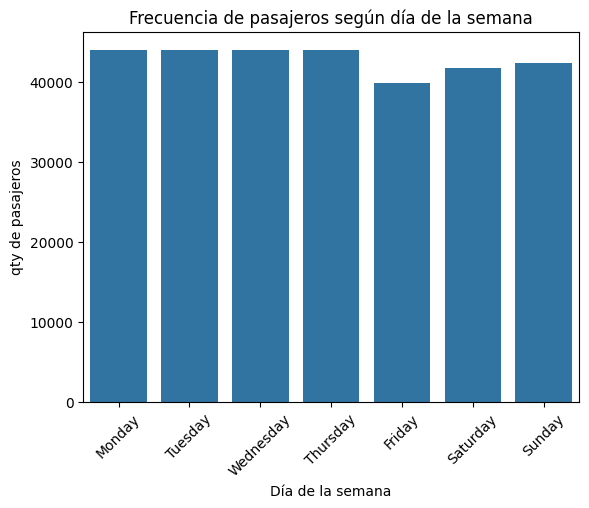

In [ ]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_frecuencia['week_day'] = pd.Categorical(df_frecuencia['week_day'], categories=order, ordered=True)
sns.barplot(x='week_day', y='frecuencia', data=df_frecuencia)
plt.title('Frecuencia de pasajeros según día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('qty de pasajeros')
plt.xticks(rotation=45)
plt.show()

##4.2.- Análisis atributo **airline**, **ch_code** y **num_code**:

In [ ]:
df['airline'].head()

,airline
0,Air India
1,Air India
2,Air India
3,Air India
4,Air India


In [ ]:
df['airline'].unique()

array(['Air India', 'Vistara', 'SpiceJet', 'AirAsia', 'GO FIRST',
       'Indigo', 'Trujet', 'StarAir'], dtype=object)

In [ ]:
df['airline'].value_counts()

,count
airline,
Vistara,127859
Air India,80892
Indigo,43120
GO FIRST,23177
AirAsia,16098
SpiceJet,9011
StarAir,61
Trujet,41


In [ ]:
df['ch_code'].head()

,ch_code
0,AI
1,AI
2,AI
3,AI
4,AI


In [ ]:
df['ch_code'].unique()

array(['AI', 'UK', 'SG', 'I5', 'G8', '6E', '2T', 'S5'], dtype=object)

Los datos contenidos en el atributo **ch_code** corresponden a los códigos asociados a las aerolíneas. Dado que corresponde a un idenfificador único, a diferencia del atributo **airline** que puede ser escrito de múltiples formas distintas, se conservará **ch_code** y se suprimirá el atributo **airline** y **num_code**

In [ ]:
df.drop('airline', axis= 1, inplace=True)

In [ ]:
df.drop('num_code', axis = 1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300259 non-null  datetime64[ns]
 1   ch_code     300259 non-null  object        
 2   dep_time    300259 non-null  object        
 3   from        300259 non-null  object        
 4   time_taken  300259 non-null  object        
 5   stop        300259 non-null  object        
 6   arr_time    300259 non-null  object        
 7   to          300259 non-null  object        
 8   price       300259 non-null  object        
 9   Class       300259 non-null  object        
 10  week_day    300259 non-null  object        
dtypes: datetime64[ns](1), object(10)
memory usage: 27.5+ MB


##4.3.- Análisis atributo **dep_time**:

In [ ]:
df['dep_time'].head()

,dep_time
0,18:00:00
1,19:00:00
2,20:00:00
3,21:25:00
4,17:15:00


In [ ]:
df['dep_time'].value_counts()

,count
dep_time,
07:00:00,8760
10:25:00,7693
19:00:00,5738
09:45:00,5468
08:30:00,4955
...,...
22:05:00,18
03:30:00,18
00:15:00,15


In [ ]:
df['dep_time'].unique()

array([datetime.time(18, 0), datetime.time(19, 0), datetime.time(20, 0),
       datetime.time(21, 25), datetime.time(17, 15),
       datetime.time(19, 50), datetime.time(21, 15),
       datetime.time(18, 40), datetime.time(20, 35),
       datetime.time(21, 35), datetime.time(17, 20),
       datetime.time(20, 40), datetime.time(16, 15), datetime.time(16, 5),
       datetime.time(20, 15), datetime.time(16, 55),
       datetime.time(17, 30), datetime.time(17, 35),
       datetime.time(17, 25), datetime.time(7, 0), datetime.time(8, 0),
       datetime.time(9, 0), datetime.time(14, 30), datetime.time(17, 50),
       datetime.time(5, 55), datetime.time(13, 40), datetime.time(12, 55),
       datetime.time(8, 50), datetime.time(17, 45), datetime.time(7, 5),
       datetime.time(18, 30), datetime.time(4, 55), datetime.time(17, 10),
       datetime.time(9, 30), datetime.time(16, 30), datetime.time(9, 45),
       datetime.time(8, 10), datetime.time(10, 15), datetime.time(7, 30),
       datetime.t

In [ ]:
print (f'El atributo analizado tiene {len(df['dep_time'].unique())} elementos distintos')

El atributo analizado tiene 251 elementos distintos


Dada la cantidad de elementos únicos que posee el atributo analizado, se propone clasisficarlos según bloque horario. Para tales efectos se procederá de la siguiente forma:
* **Bloque 1:** entre las 00:00 y las 02:59
* **Bloque 2:** entre las 03:00 y las 05:59
* **Bloque 3:** entre las 06:00 y las 08:59
* **Bloque 4:** entre las 09:00 y las 11:59
* **Bloque 5:** entre las 12:00 y las 14:59
* **Bloque 6:** entre las 15:00 y las 17:59
* **Bloque 7:** entre las 18:00 y las 20:59
* **Bloque 8:** entre las 21:00 y las 23:59

In [ ]:
def categorize_dep_time(time_obj):
    hour = time_obj.hour
    if 0 <= hour <= 2:
        return 'Bloque 1'
    elif 3 <= hour <= 5:
        return 'Bloque 2'
    elif 6 <= hour <= 8:
        return 'Bloque 3'
    elif 9 <= hour <= 11:
        return 'Bloque 4'
    elif 12 <= hour <= 14:
        return 'Bloque 5'
    elif 15 <= hour <= 17:
        return 'Bloque 6'
    elif 18 <= hour <= 20:
        return 'Bloque 7'
    elif 21 <= hour <= 23:
        return 'Bloque 8'
    else:
        return 'Unknown'

In [ ]:
df['bloque_horario'] = df['dep_time'].apply(categorize_dep_time)
df['bloque_horario'].value_counts()

,count
bloque_horario,
Bloque 3,68153
Bloque 4,58450
Bloque 7,56843
Bloque 6,43161
Bloque 5,36000
Bloque 8,25773
Bloque 2,10859
Bloque 1,1020


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            300259 non-null  datetime64[ns]
 1   ch_code         300259 non-null  object        
 2   dep_time        300259 non-null  object        
 3   from            300259 non-null  object        
 4   time_taken      300259 non-null  object        
 5   stop            300259 non-null  object        
 6   arr_time        300259 non-null  object        
 7   to              300259 non-null  object        
 8   price           300259 non-null  object        
 9   Class           300259 non-null  object        
 10  week_day        300259 non-null  object        
 11  bloque_horario  300259 non-null  object        
dtypes: datetime64[ns](1), object(11)
memory usage: 29.8+ MB


##4.4.- Análisis atributo **from**:

In [ ]:
df['from'].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

El atributo **from** sólo cuenta con 6 elementos distintosm los cuales corresponden al origen de los viajes registrados. Este atributo puede ser considerado como una variable categórica.

##4.5.- Análisis atributo **time_taken**:

In [ ]:
len(df['time_taken'].unique())

483

In [ ]:
df['time_taken'].head(10)

,time_taken
0,02h 00m
1,02h 15m
2,24h 45m
3,26h 30m
4,06h 40m
5,02h 10m
6,17h 45m
7,22h 45m
8,17h 55m
9,02h 15m


In [ ]:
df['time_taken'] = df['time_taken'].astype(str)

In [ ]:
df_tiempo_viaje = df['time_taken'].str.split(' ', expand=True)

In [ ]:
df_tiempo_viaje.rename(columns={0: 'tmpo_horas', 1: 'tmpo_minutos'}, inplace=True)

In [ ]:
df_tiempo_viaje

,tmpo_horas,tmpo_minutos
0,02h,00m
1,02h,15m
2,24h,45m
3,26h,30m
4,06h,40m
...,...,...
206769,13h,50m
206770,13h,50m
206771,20h,35m
206772,23h,20m


In [ ]:
df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'].str.replace('h', '')
df_tiempo_viaje['tmpo_minutos'] = df_tiempo_viaje['tmpo_minutos'].str.replace('m', '')
df_tiempo_viaje.head()

,tmpo_horas,tmpo_minutos
0,02,00
1,02,15
2,24,45
3,26,30
4,06,40


In [ ]:
len(df_tiempo_viaje['tmpo_horas'].unique())

53

In [ ]:
df_tiempo_viaje['tmpo_horas'].unique()

array(['02', '24', '26', '06', '17', '22', '11', '15', '21', '05', '16',
       '28', '19', '23', '27', '12', '14', '18', '03', '25', '08', '20',
       '10', '04', '07', '13', '30', '09', '29', '01', '31', '37', '36',
       '40', '34', '47', '35', '32', '45', '33', '39', '7', '41', '38',
       '1.03', '1.02', '2', '00', '1.01', '5', '42', '49', '44'],
      dtype=object)

In [ ]:
df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'].astype(float)

In [ ]:
df_tiempo_viaje['tmpo_minutos'].unique()

array(['00', '15', '45', '30', '40', '10', '55', '25', '50', '35', '20',
       '05', '04', '', '59', '24'], dtype=object)

In [ ]:
df_tiempo_viaje[df_tiempo_viaje['tmpo_minutos']=='']

,tmpo_horas,tmpo_minutos
96486,1.03,
104676,1.02,
111315,1.03,
154007,1.01,


In [ ]:
df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'].astype(float)

In [ ]:
df_tiempo_viaje['tmpo_minutos'].unique()

array(['00', '15', '45', '30', '40', '10', '55', '25', '50', '35', '20',
       '05', '04', '', '59', '24'], dtype=object)

In [ ]:
df_tiempo_viaje[df_tiempo_viaje['tmpo_minutos']=='']

,tmpo_horas,tmpo_minutos
96486,1.03,
104676,1.02,
111315,1.03,
154007,1.01,


In [ ]:
df_tiempo_viaje['tmpo_minutos'] = np.where(df_tiempo_viaje['tmpo_minutos'] == '', 0, df_tiempo_viaje['tmpo_minutos'])

In [ ]:
df_tiempo_viaje['tmpo_minutos'].unique()

array(['00', '15', '45', '30', '40', '10', '55', '25', '50', '35', '20',
       '05', '04', 0, '59', '24'], dtype=object)

In [ ]:
df_tiempo_viaje['tmpo_minutos'] = df_tiempo_viaje['tmpo_minutos'].astype(float)

In [ ]:
df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'] + df_tiempo_viaje['tmpo_minutos'] / 60

In [ ]:
df_tiempo_viaje['tmpo_horas']

,tmpo_horas
0,2.000000
1,2.250000
2,24.750000
3,26.500000
4,6.666667
...,...
206769,13.833333
206770,13.833333
206771,20.583333
206772,23.333333


<Axes: xlabel='tmpo_horas', ylabel='Count'>

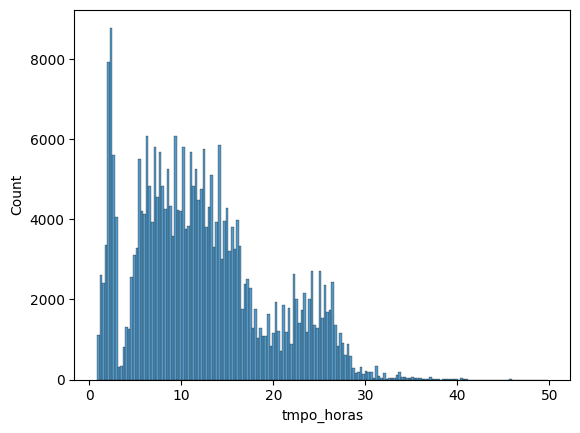

In [ ]:
sns.histplot(df_tiempo_viaje['tmpo_horas'])

Los viajes en avión se clasifican principalmente según su duración en vuelos de corta, media y larga distancia (o alcance), basándose en el tiempo de vuelo y la autonomía de la aeronave.

La clasificación habitual:
- Corta Distancia (Short-haul): menos de 3 horas.
- Media Distancia (Medium-haul): usualmente entre 3 y 6 horas.
- Larga Distancia (Long-haul): Vuelos internacionales que suelen durar entre 6 y 12 horas.
- Ultralarga Distancia (Ultra long-haul): Vuelos que superan las 12 o 16 horas de duración, como rutas transcontinentales.

In [ ]:
def categorize_tmpo_viaje(hours_float):
    # The input 'hours_float' is already the hour value as a float
    if 0 <= hours_float < 3:
        return 'Corta distancia'
    elif 3 <= hours_float < 6:
        return 'media distancia'
    elif 6 <= hours_float < 12:
        return 'larga distancia'
    elif hours_float >= 12:
        return 'Ultra larga distancia'
    else:
        return 'Unknown'

In [ ]:
df_tiempo_viaje['tipo_viaje'] = df_tiempo_viaje['tmpo_horas'].apply(categorize_tmpo_viaje)
df_tiempo_viaje['tipo_viaje'].value_counts()

,count
tipo_viaje,
Ultra larga distancia,138449
larga distancia,102003
Corta distancia,35584
media distancia,24223


<Axes: xlabel='tipo_viaje', ylabel='Count'>

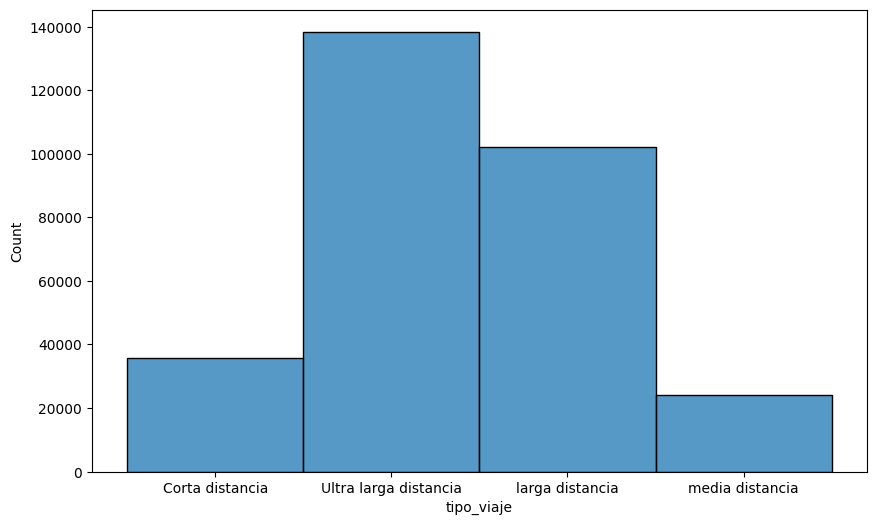

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_tiempo_viaje['tipo_viaje'])

In [ ]:
df = pd.concat([df,df_tiempo_viaje], axis = 1)

In [ ]:
df.head()

,date,ch_code,dep_time,from,time_taken,stop,arr_time,to,price,Class,week_day,bloque_horario,tmpo_horas,tmpo_minutos,tipo_viaje
0,2022-02-11,AI,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,2.000000,0.0,Corta distancia
1,2022-02-11,AI,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,2.250000,15.0,Corta distancia
2,2022-02-11,AI,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220,business,Friday,Bloque 7,24.750000,45.0,Ultra larga distancia
3,2022-02-11,AI,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450,business,Friday,Bloque 8,26.500000,30.0,Ultra larga distancia
4,2022-02-11,AI,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690,business,Friday,Bloque 6,6.666667,40.0,larga distancia


In [ ]:
df.drop(columns=['time_taken', 'tmpo_horas', 'tmpo_minutos'], inplace=True)

In [ ]:
df.head()

,date,ch_code,dep_time,from,stop,arr_time,to,price,Class,week_day,bloque_horario,tipo_viaje
0,2022-02-11,AI,18:00:00,Delhi,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
1,2022-02-11,AI,19:00:00,Delhi,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
2,2022-02-11,AI,20:00:00,Delhi,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220,business,Friday,Bloque 7,Ultra larga distancia
3,2022-02-11,AI,21:25:00,Delhi,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450,business,Friday,Bloque 8,Ultra larga distancia
4,2022-02-11,AI,17:15:00,Delhi,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690,business,Friday,Bloque 6,larga distancia


##4.6.- Análisis atributo **stop**:

In [ ]:
df['stop'] = df['stop'].str.extract(r'(non-stop|[0-9]+-stop|2\+-stop)', expand=False)
df['stop'] = df['stop'].str.replace('\n', '', regex=False).str.replace('\t', '', regex=False).str.strip()
df['stop'].value_counts()

,count
stop,
1-stop,250927
non-stop,36044
2+-stop,13288


In [ ]:
df['stop'].unique()

array(['non-stop', '1-stop', '2+-stop'], dtype=object)

In [ ]:
df

,date,ch_code,dep_time,from,stop,arr_time,to,price,Class,week_day,bloque_horario,tipo_viaje
0,2022-02-11,AI,18:00:00,Delhi,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
1,2022-02-11,AI,19:00:00,Delhi,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
2,2022-02-11,AI,20:00:00,Delhi,1-stop,20:45:00,Mumbai,42220,business,Friday,Bloque 7,Ultra larga distancia
3,2022-02-11,AI,21:25:00,Delhi,1-stop,23:55:00,Mumbai,44450,business,Friday,Bloque 8,Ultra larga distancia
4,2022-02-11,AI,17:15:00,Delhi,1-stop,23:55:00,Mumbai,46690,business,Friday,Bloque 6,larga distancia
...,...,...,...,...,...,...,...,...,...,...,...,...
206769,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7697,economy,Thursday,Bloque 3,Ultra larga distancia
206770,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7709,economy,Thursday,Bloque 3,Ultra larga distancia
206771,2022-03-31,UK,12:30:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 5,Ultra larga distancia
206772,2022-03-31,UK,09:45:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 4,Ultra larga distancia


In [ ]:
df.describe()

,date
count,300259
mean,2022-03-08 00:06:31.342141696
min,2022-02-11 00:00:00
25%,2022-02-25 00:00:00
50%,2022-03-08 00:00:00
75%,2022-03-20 00:00:00
max,2022-03-31 00:00:00


##4.7.-  Análisis atributo **arr_time**:

En la industria aérea, el precio no solo lo dicta la distancia, sino la conveniencia.

Existen horas "pico" en los aeropuertos que encarecen el boleto debido a la alta demanda y los costos de operación:

- 07:00 - 10:00 Muy Alto - Máxima demanda corporativa y conexiones.
- 11:00 - 16:00 Medio - Preferido por familias y turistas.
- 17:00 - 20:00 Alto - Viajeros que regresan a casa tras el trabajo.
- 23:00 - 05:00 Bajo - "Red-eye flights" (vuelos nocturnos) menos deseados.

In [ ]:
df['arr_time'].unique()

array([datetime.time(20, 0), datetime.time(21, 15), datetime.time(20, 45),
       datetime.time(23, 55), datetime.time(22, 0), datetime.time(15, 0),
       datetime.time(17, 25), datetime.time(14, 30), datetime.time(8, 35),
       datetime.time(8, 5), datetime.time(18, 15), datetime.time(21, 50),
       datetime.time(8, 15), datetime.time(20, 15), datetime.time(11, 25),
       datetime.time(20, 5), datetime.time(23, 30), datetime.time(13, 0),
       datetime.time(20, 20), datetime.time(11, 40),
       datetime.time(22, 50), datetime.time(9, 5), datetime.time(10, 10),
       datetime.time(22, 10), datetime.time(11, 15), datetime.time(18, 0),
       datetime.time(21, 35), datetime.time(23, 25),
       datetime.time(15, 15), datetime.time(19, 15),
       datetime.time(11, 10), datetime.time(15, 5), datetime.time(11, 35),
       datetime.time(16, 25), datetime.time(23, 0), datetime.time(16, 0),
       datetime.time(14, 0), datetime.time(0, 10), datetime.time(8, 20),
       datetime.time(12

In [ ]:
df['franja_arribo'] = df['arr_time'].apply(categorize_arr_time)


In [ ]:
df['franja_arribo'].value_counts()

,count
franja_arribo,
Alto,139735
Muy Alto,74970
Medio,68860
Bajo,16694


In [ ]:
df.head(20)

,date,ch_code,dep_time,from,stop,arr_time,to,price,Class,week_day,bloque_horario,tipo_viaje,franja_arribo
0,2022-02-11,AI,18:00:00,Delhi,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia,Alto
1,2022-02-11,AI,19:00:00,Delhi,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia,Alto
2,2022-02-11,AI,20:00:00,Delhi,1-stop,20:45:00,Mumbai,42220,business,Friday,Bloque 7,Ultra larga distancia,Alto
3,2022-02-11,AI,21:25:00,Delhi,1-stop,23:55:00,Mumbai,44450,business,Friday,Bloque 8,Ultra larga distancia,Alto
4,2022-02-11,AI,17:15:00,Delhi,1-stop,23:55:00,Mumbai,46690,business,Friday,Bloque 6,larga distancia,Alto
5,2022-02-11,UK,19:50:00,Delhi,non-stop,22:00:00,Mumbai,50264,business,Friday,Bloque 7,Corta distancia,Alto
6,2022-02-11,AI,21:15:00,Delhi,1-stop,15:00:00,Mumbai,50669,business,Friday,Bloque 8,Ultra larga distancia,Medio
7,2022-02-11,AI,18:40:00,Delhi,1-stop,17:25:00,Mumbai,51059,business,Friday,Bloque 7,Ultra larga distancia,Medio
8,2022-02-11,UK,20:35:00,Delhi,1-stop,14:30:00,Mumbai,51731,business,Friday,Bloque 7,Ultra larga distancia,Medio
9,2022-02-11,UK,19:00:00,Delhi,non-stop,21:15:00,Mumbai,53288,business,Friday,Bloque 7,Corta distancia,Alto


##4.8.- Análisis atributo **price**

In [ ]:
df.dropna(subset=['price'], inplace=True)

In [ ]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 300259 entries, 0 to 206773
Series name: price
Non-Null Count   Dtype 
--------------   ----- 
300259 non-null  object
dtypes: object(1)
memory usage: 4.6+ MB


Dado que el atributo **price** es de tipo object. Se procederá a revisar por separado los DataFrame originales para identifica y corregir el motivo que origina que el atributo price sea de tipo object.

In [ ]:
df

,date,ch_code,dep_time,from,stop,arr_time,to,price,Class,week_day,bloque_horario,tipo_viaje,franja_arribo
0,2022-02-11,AI,18:00:00,Delhi,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia,Alto
1,2022-02-11,AI,19:00:00,Delhi,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia,Alto
2,2022-02-11,AI,20:00:00,Delhi,1-stop,20:45:00,Mumbai,42220,business,Friday,Bloque 7,Ultra larga distancia,Alto
3,2022-02-11,AI,21:25:00,Delhi,1-stop,23:55:00,Mumbai,44450,business,Friday,Bloque 8,Ultra larga distancia,Alto
4,2022-02-11,AI,17:15:00,Delhi,1-stop,23:55:00,Mumbai,46690,business,Friday,Bloque 6,larga distancia,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7697,economy,Thursday,Bloque 3,Ultra larga distancia,Alto
206770,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7709,economy,Thursday,Bloque 3,Ultra larga distancia,Alto
206771,2022-03-31,UK,12:30:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 5,Ultra larga distancia,Muy Alto
206772,2022-03-31,UK,09:45:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 4,Ultra larga distancia,Muy Alto


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            300259 non-null  datetime64[ns]
 1   ch_code         300259 non-null  object        
 2   dep_time        300259 non-null  object        
 3   from            300259 non-null  object        
 4   stop            300259 non-null  object        
 5   arr_time        300259 non-null  object        
 6   to              300259 non-null  object        
 7   price           300259 non-null  object        
 8   Class           300259 non-null  object        
 9   week_day        300259 non-null  object        
 10  bloque_horario  300259 non-null  object        
 11  tipo_viaje      300259 non-null  object        
 12  franja_arribo   300259 non-null  object        
dtypes: datetime64[ns](1), object(12)
memory usage: 32.1+ MB


In [ ]:
df.loc[:, 'price'] = df['price'].astype(str).str.replace(',', '').astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            300259 non-null  datetime64[ns]
 1   ch_code         300259 non-null  object        
 2   dep_time        300259 non-null  object        
 3   from            300259 non-null  object        
 4   stop            300259 non-null  object        
 5   arr_time        300259 non-null  object        
 6   to              300259 non-null  object        
 7   price           300259 non-null  object        
 8   Class           300259 non-null  object        
 9   week_day        300259 non-null  object        
 10  bloque_horario  300259 non-null  object        
 11  tipo_viaje      300259 non-null  object        
 12  franja_arribo   300259 non-null  object        
dtypes: datetime64[ns](1), object(12)
memory usage: 32.1+ MB


In [ ]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
 11  Class       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 8.6+ MB


In [ ]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
 11  Class       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 8.6+ MB


In [ ]:
list(df_business['price'].unique())

[25612,
 42220,
 44450,
 46690,
 50264,
 50669,
 51059,
 51731,
 53288,
 56081,
 57074,
 57868,
 59996,
 61273,
 63737,
 74640,
 76768,
 78376,
 25736,
 36496,
 37286,
 37682,
 37617,
 40296,
 40582,
 42252,
 43964,
 44328,
 44060,
 45896,
 46265,
 47396,
 48281,
 49256,
 50822,
 50992,
 51496,
 51641,
 53582,
 56345,
 57801,
 58524,
 59976,
 61721,
 62057,
 67657,
 77737,
 79977,
 95657,
 30104,
 30092,
 32456,
 33197,
 33136,
 33926,
 34982,
 36652,
 38056,
 39580,
 42770,
 43521,
 44664,
 45145,
 45222,
 45459,
 49737,
 49872,
 51342,
 53881,
 54284,
 54898,
 55416,
 58865,
 66044,
 70793,
 82816,
 85527,
 86137,
 86776,
 91575,
 22152,
 29622,
 29776,
 31462,
 32646,
 34472,
 35532,
 36577,
 36712,
 37048,
 37417,
 37256,
 37900,
 39622,
 39859,
 40447,
 41281,
 41113,
 42956,
 44081,
 44025,
 44622,
 45156,
 45336,
 47217,
 49896,
 50969,
 51384,
 51697,
 53164,
 55696,
 58876,
 59033,
 59571,
 60601,
 60713,
 64924,
 71056,
 76953,
 80470,
 85801,
 28872,
 29837,
 29777,
 36995,


Se identifican registros que contienen '**,**'

In [ ]:
df['price'] = df['price'].astype(str)

In [ ]:
df['price'] = df['price'].str.replace(',', '')

In [ ]:
df['price'] = df['price'].astype(int)

In [ ]:
df['price'].info()

<class 'pandas.core.series.Series'>
Index: 300259 entries, 0 to 206773
Series name: price
Non-Null Count   Dtype
--------------   -----
300259 non-null  int64
dtypes: int64(1)
memory usage: 4.6 MB


##4.9.-  Análisis gráfico Univariado y Bivariado

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            300259 non-null  datetime64[ns]
 1   ch_code         300259 non-null  object        
 2   dep_time        300259 non-null  object        
 3   from            300259 non-null  object        
 4   stop            300259 non-null  object        
 5   arr_time        300259 non-null  object        
 6   to              300259 non-null  object        
 7   price           300259 non-null  int64         
 8   Class           300259 non-null  object        
 9   week_day        300259 non-null  object        
 10  bloque_horario  300259 non-null  object        
 11  tipo_viaje      300259 non-null  object        
 12  franja_arribo   300259 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(11)
memory usage: 32.1+ MB


In [ ]:
df_modelo = df[['ch_code','from','stop','to','Class','week_day','bloque_horario','tipo_viaje','franja_arribo','price']]

In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ch_code         300259 non-null  object
 1   from            300259 non-null  object
 2   stop            300259 non-null  object
 3   to              300259 non-null  object
 4   Class           300259 non-null  object
 5   week_day        300259 non-null  object
 6   bloque_horario  300259 non-null  object
 7   tipo_viaje      300259 non-null  object
 8   franja_arribo   300259 non-null  object
 9   price           300259 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 25.2+ MB


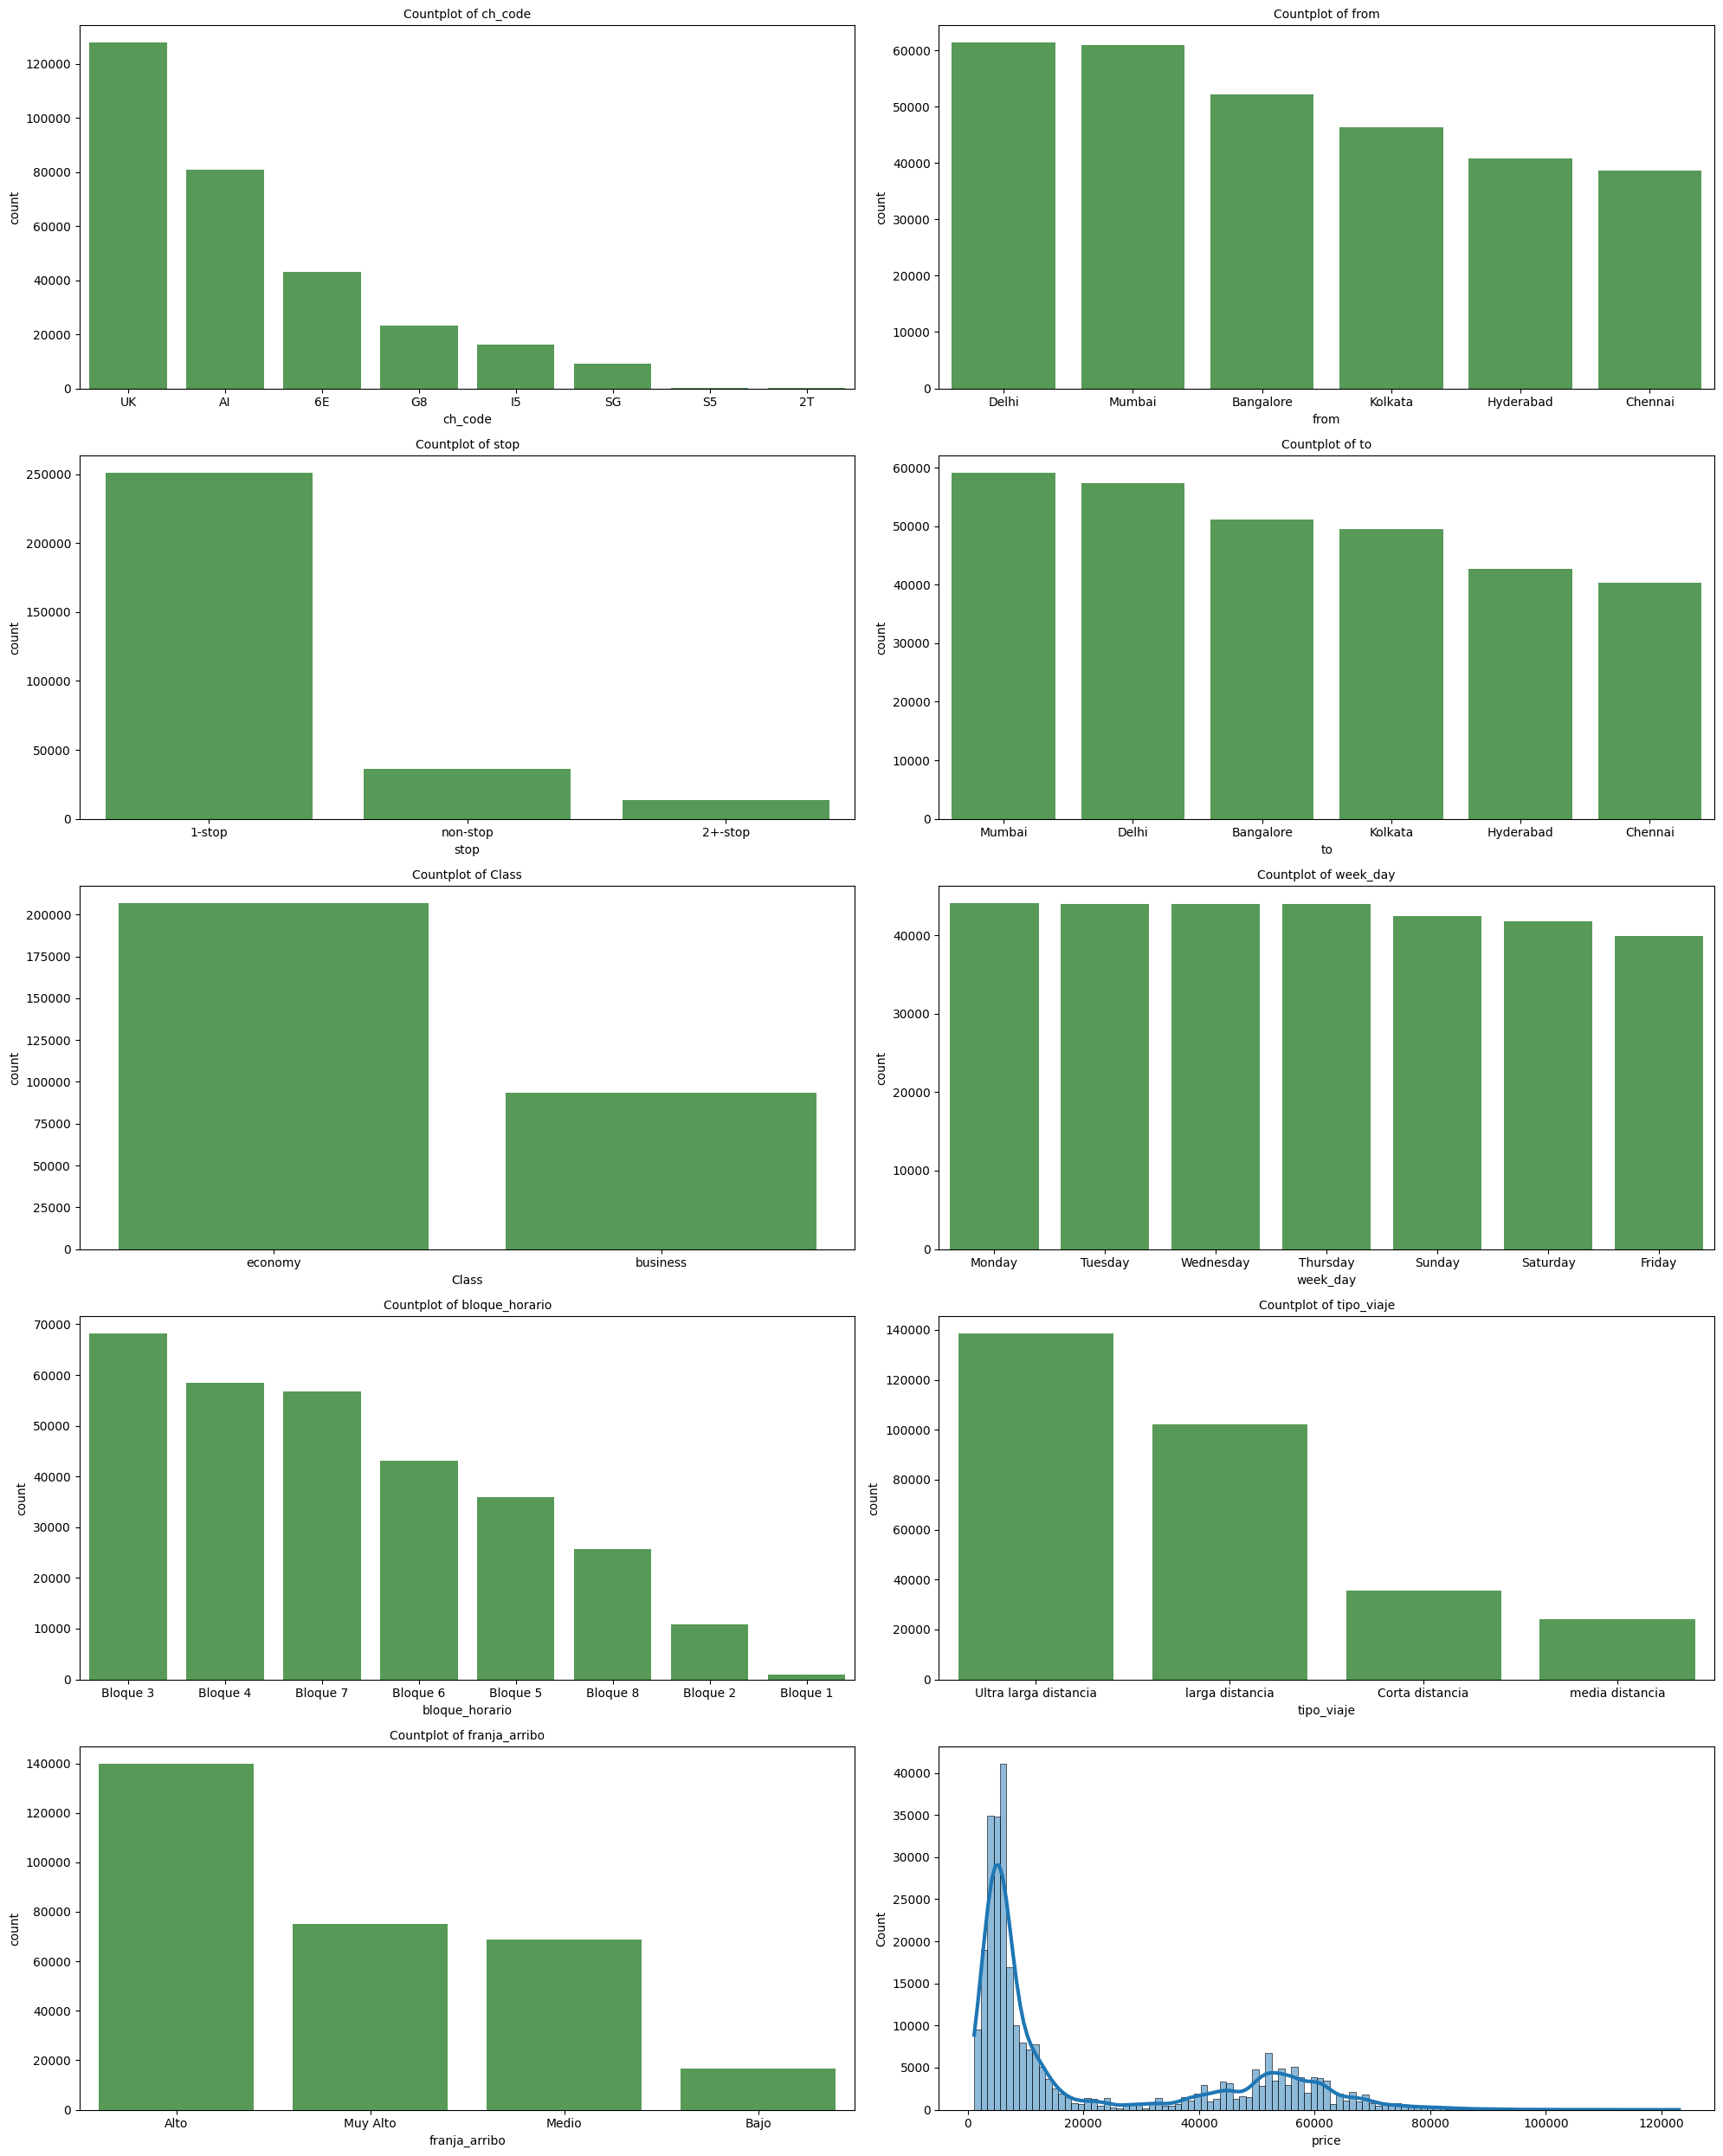

In [ ]:
from typing import OrderedDict
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
axes_flat = axes.flatten()
for i, col_name in enumerate(df_modelo.columns[:10]): # Tomamos las12 columnas
    ax = axes_flat[i]
    if not pd.api.types.is_numeric_dtype(df_modelo[col_name]):
        # Get the order by frequency
        order = df[col_name].value_counts().index
        # Gráfico para categóricos
        sns.countplot(x=col_name, data=df_modelo, ax=ax, color='green',alpha=0.7, order=order)
        ax.set_title(f"Countplot of {col_name}", fontsize=10)
    else: # Si es numérico
        sns.histplot(
          data=df_modelo,
          x=col_name,
          kde=True,
          ax=ax,
          line_kws={'color': 'red', 'linewidth': 3}, # Forzar color y grosor de la línea
          )
plt.tight_layout()
plt.show()

**Conclusiones del análisis gráfico**:


1.   Las líneas aéreas UK y AI concentras aprpximádamente, el 80% de los vuelos (e ingresos) registrados.
2.   Los vuelos más frecuentes son entre Munbai y Delhi (ida y regreso).
3. Los vuelos que consideran 1 parada, son significativamente mayores a los vuelos directos junto con los vuelos que consideran 2 o más escalas.
4.  Los ticket en clase economic prácticamente doblan a los tickets que se venden para clase business.
5. Los días lunes, martes y miércoles se registran la maypr cantidad de tickets, siendo muy similares en cuanto a cantidad. Sin embargo se observa una disminución de tickets a contar del día jueves, los cuales van disminuyendo progesivamente hacia el día domingo.
6. Los clientes prefieren el bloque horario N°3 para viajar (Contemplado entre las 6:00 y las 9:00 AM), mientras que el bloque N°1 (entre las 0:00 y las 3:00) es el menos utilizado.
7. Los tickets más recurrentes son los tickets relacionados con distancias ultra largas. A medida que la distancia de viaje se acorta, va disminuyendo la preferencia del uso del avión, dado que a menor distancia que se deba recorrer, hay mayor oferta de sustitutos.
8. El precio y la cantidad de ticket asociados a las clases economic y business tienen comportamientos distintos. Se emiten una menor cantidad de tickets de clase business, los cuales tienen un precio considerablemente mayor, comparado con los ticket de clase economic. **NOTA:** Por este motivo, se considerará realizar modelos predictivos separados. Uno para la clase business y otro para la clase Economic.



#5.- Función para encapsular procesamiento de datos

In [ ]:
def tratamiento_datos():
  df_business = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Desafio_Prueba_ML/business.xlsx', sheet_name='business.csv')
  df_economy = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Desafio_Prueba_ML/economy.xlsx', sheet_name='economy.csv')

  atributos_business = list(df_business.columns)
  atributos_economy = list(df_economy.columns)

  if atributos_business == atributos_economy:
    print('Los DataFrame contienen los mismos atributos')
  else:
    print('Los DataFrame contienen los atributos distintos')

  df_business['Class'] = 'business'
  df_economy['Class'] = 'economy'

  df = pd.concat([df_business, df_economy])
  df.drop_duplicates(inplace=True)

  df['date'] = df['date'].dt.normalize()
  df['week_day'] = df['date'].dt.day_name()
  df['week_day']

  df.drop('airline', axis= 1, inplace=True)
  df.drop('num_code', axis = 1, inplace=True)

  df['bloque_horario'] = df['dep_time'].apply(categorize_dep_time)

  df['time_taken'] = df['time_taken'].astype(str)
  df_tiempo_viaje = df['time_taken'].str.split(' ', expand=True)
  df_tiempo_viaje.rename(columns={0: 'tmpo_horas', 1: 'tmpo_minutos'}, inplace=True)

  df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'].str.replace('h', '')
  df_tiempo_viaje['tmpo_minutos'] = df_tiempo_viaje['tmpo_minutos'].str.replace('m', '')

  df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'].astype(float)
  df_tiempo_viaje[df_tiempo_viaje['tmpo_minutos']=='']

  df_tiempo_viaje['tmpo_minutos'] = np.where(df_tiempo_viaje['tmpo_minutos'] == '', 0, df_tiempo_viaje['tmpo_minutos'])
  df_tiempo_viaje['tmpo_minutos'] = df_tiempo_viaje['tmpo_minutos'].astype(float)
  df_tiempo_viaje['tmpo_horas'] = df_tiempo_viaje['tmpo_horas'] + df_tiempo_viaje['tmpo_minutos'] / 60

  df_tiempo_viaje['tipo_viaje'] = df_tiempo_viaje['tmpo_horas'].apply(categorize_tmpo_viaje)

  df = pd.concat([df,df_tiempo_viaje], axis = 1)

  df.drop(columns=['time_taken', 'tmpo_horas', 'tmpo_minutos'], inplace=True)

  df['stop'] = df['stop'].str.extract(r'(non-stop|[0-9]+-stop|2\+-stop)', expand=False)
  df['stop'] = df['stop'].str.replace('\n', '', regex=False).str.replace('\t', '', regex=False).str.strip()

  df.dropna(subset=['price'], inplace=True)

  df.loc[:, 'price'] = df['price'].astype(str).str.replace(',', '').astype(int)

  df['price'] = df['price'].astype(str)
  df['price'] = df['price'].str.replace(',', '')
  df['price'] = df['price'].astype(int)
  return df


In [ ]:
df_test_funcion_encapsulada = tratamiento_datos()

Los DataFrame contienen los mismos atributos


In [ ]:
df_test_funcion_encapsulada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            300259 non-null  datetime64[ns]
 1   ch_code         300259 non-null  object        
 2   dep_time        300259 non-null  object        
 3   from            300259 non-null  object        
 4   stop            300259 non-null  object        
 5   arr_time        300259 non-null  object        
 6   to              300259 non-null  object        
 7   price           300259 non-null  int64         
 8   Class           300259 non-null  object        
 9   week_day        300259 non-null  object        
 10  bloque_horario  300259 non-null  object        
 11  tipo_viaje      300259 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 29.8+ MB


In [ ]:
df_test_funcion_encapsulada

,date,ch_code,dep_time,from,stop,arr_time,to,price,Class,week_day,bloque_horario,tipo_viaje
0,2022-02-11,AI,18:00:00,Delhi,non-stop,20:00:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
1,2022-02-11,AI,19:00:00,Delhi,non-stop,21:15:00,Mumbai,25612,business,Friday,Bloque 7,Corta distancia
2,2022-02-11,AI,20:00:00,Delhi,1-stop,20:45:00,Mumbai,42220,business,Friday,Bloque 7,Ultra larga distancia
3,2022-02-11,AI,21:25:00,Delhi,1-stop,23:55:00,Mumbai,44450,business,Friday,Bloque 8,Ultra larga distancia
4,2022-02-11,AI,17:15:00,Delhi,1-stop,23:55:00,Mumbai,46690,business,Friday,Bloque 6,larga distancia
...,...,...,...,...,...,...,...,...,...,...,...,...
206769,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7697,economy,Thursday,Bloque 3,Ultra larga distancia
206770,2022-03-31,UK,07:05:00,Chennai,1-stop,20:55:00,Hyderabad,7709,economy,Thursday,Bloque 3,Ultra larga distancia
206771,2022-03-31,UK,12:30:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 5,Ultra larga distancia
206772,2022-03-31,UK,09:45:00,Chennai,1-stop,09:05:00,Hyderabad,8640,economy,Thursday,Bloque 4,Ultra larga distancia


#6.- Codificación y escalado de variables

In [ ]:
def columnas_binarias(df): #función que identifica los atributos binarios
  binarias = []
  for i in df.columns:
    if len(df[i].unique()) == 2:
      binarias.append(i)
  return binarias

def codificacion_binaria(df, columnas):#Función que codifica atributo categórico binario o una lista de ellos
  le = LabelEncoder()
  mappings = {}
  df_processed = df.copy() # Create a copy to preserve the original DataFrame

  if isinstance(columnas, str):
      encoded_col_name = columnas + '_encoded'
      df_processed[encoded_col_name] = le.fit_transform(df_processed[columnas])
      mappings[columnas] = {0: le.classes_[0], 1: le.classes_[1]}
  elif isinstance(columnas, list):
      for col_name in columnas:
          encoded_col_name = col_name + '_encoded'
          le.fit(df_processed[col_name])
          df_processed[encoded_col_name] = le.transform(df_processed[col_name])
          mappings[col_name] = {0: le.classes_[0], 1: le.classes_[1]}
  else:
      raise ValueError("El argumento 'columnas' debe ser una cadena o una lista de cadenas.")
  return df_processed

In [ ]:
columnas_binarias(df_modelo)

['Class']

In [ ]:
df_atributos_binarios_codificados = codificacion_binaria(df_modelo, columnas_binarias(df_modelo))

In [ ]:
df_atributos_binarios_codificados

,ch_code,from,stop,to,Class,week_day,bloque_horario,tipo_viaje,franja_arribo,price,Class_encoded
0,AI,Delhi,non-stop,Mumbai,business,Friday,Bloque 7,Corta distancia,Alto,25612,0
1,AI,Delhi,non-stop,Mumbai,business,Friday,Bloque 7,Corta distancia,Alto,25612,0
2,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 7,Ultra larga distancia,Alto,42220,0
3,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 8,Ultra larga distancia,Alto,44450,0
4,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 6,larga distancia,Alto,46690,0
...,...,...,...,...,...,...,...,...,...,...,...
206769,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 3,Ultra larga distancia,Alto,7697,1
206770,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 3,Ultra larga distancia,Alto,7709,1
206771,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 5,Ultra larga distancia,Muy Alto,8640,1
206772,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 4,Ultra larga distancia,Muy Alto,8640,1


In [ ]:
def identifica_columnas_multiclase(df):
  multi_class_cols = []
  binary_cols = columnas_binarias(df) # Reusing the previously defined function
  for col in df.columns:
    # Consider only object type columns for multi-class identification
    if df[col].dtype == 'object' and col not in binary_cols:
      if len(df[col].unique()) > 2:
        multi_class_cols.append(col)
  return multi_class_cols

In [ ]:
def codificacion_multiclase(df, columnas):
  ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

  # Convert single column name to a list for consistent processing
  if isinstance(columnas, str):
      cols_to_encode = [columnas]
  elif isinstance(columnas, list):
      cols_to_encode = columnas
  else:
      raise ValueError("El argumento 'columnas' debe ser una cadena o una lista de cadenas.")

  # Filter out binary columns
  binary_cols = columnas_binarias(df)
  non_binary_cols_to_encode = [col for col in cols_to_encode if col not in binary_cols]

  if not non_binary_cols_to_encode:
      print("No hay columnas multiclase para codificar.")
      return df

  # Apply OneHotEncoder to non-binary columns
  encoded_data = ohe.fit_transform(df[non_binary_cols_to_encode])
  encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(non_binary_cols_to_encode), index=df.index)
  df = pd.concat([df.drop(columns=non_binary_cols_to_encode), encoded_df], axis=1)

  return df

In [ ]:
atributos_multiclase = identifica_columnas_multiclase(df_modelo)


In [ ]:
df_multiclases_codificadas = codificacion_multiclase(df_modelo, atributos_multiclase)

In [ ]:
df_multiclases_codificadas

,Class,price,ch_code_2T,ch_code_6E,ch_code_AI,ch_code_G8,ch_code_I5,ch_code_S5,ch_code_SG,ch_code_UK,...,bloque_horario_Bloque 7,bloque_horario_Bloque 8,tipo_viaje_Corta distancia,tipo_viaje_Ultra larga distancia,tipo_viaje_larga distancia,tipo_viaje_media distancia,franja_arribo_Alto,franja_arribo_Bajo,franja_arribo_Medio,franja_arribo_Muy Alto
0,business,25612,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,business,25612,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,business,42220,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,business,44450,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,business,46690,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,economy,7697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
206770,economy,7709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
206771,economy,8640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
206772,economy,8640,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_modelo = pd.concat([df_atributos_binarios_codificados, df_multiclases_codificadas], axis = 1)

In [ ]:
df_modelo

,ch_code,from,stop,to,Class,week_day,bloque_horario,tipo_viaje,franja_arribo,price,...,bloque_horario_Bloque 7,bloque_horario_Bloque 8,tipo_viaje_Corta distancia,tipo_viaje_Ultra larga distancia,tipo_viaje_larga distancia,tipo_viaje_media distancia,franja_arribo_Alto,franja_arribo_Bajo,franja_arribo_Medio,franja_arribo_Muy Alto
0,AI,Delhi,non-stop,Mumbai,business,Friday,Bloque 7,Corta distancia,Alto,25612,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,AI,Delhi,non-stop,Mumbai,business,Friday,Bloque 7,Corta distancia,Alto,25612,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 7,Ultra larga distancia,Alto,42220,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 8,Ultra larga distancia,Alto,44450,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,AI,Delhi,1-stop,Mumbai,business,Friday,Bloque 6,larga distancia,Alto,46690,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206769,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 3,Ultra larga distancia,Alto,7697,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
206770,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 3,Ultra larga distancia,Alto,7709,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
206771,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 5,Ultra larga distancia,Muy Alto,8640,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
206772,UK,Chennai,1-stop,Hyderabad,economy,Thursday,Bloque 4,Ultra larga distancia,Muy Alto,8640,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 59 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   ch_code                           300259 non-null  object 
 1   from                              300259 non-null  object 
 2   stop                              300259 non-null  object 
 3   to                                300259 non-null  object 
 4   Class                             300259 non-null  object 
 5   week_day                          300259 non-null  object 
 6   bloque_horario                    300259 non-null  object 
 7   tipo_viaje                        300259 non-null  object 
 8   franja_arribo                     300259 non-null  object 
 9   price                             300259 non-null  int64  
 10  Class_encoded                     300259 non-null  int64  
 11  Class                             300259 non-null  object

In [ ]:
# Identificar todas las columnas con tipo de dato 'object'
object_cols = df_modelo.select_dtypes(include=['object']).columns

# Eliminar estas columnas del DataFrame
df_modelo.drop(columns=object_cols, inplace=True)

# Handle potential duplicate 'price' columns (or any other duplicates)
# Keep the first occurrence of any duplicate column name
df_modelo = df_modelo.loc[:,~df_modelo.columns.duplicated(keep='first')].copy()



In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300259 entries, 0 to 206773
Data columns (total 48 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   price                             300259 non-null  int64  
 1   Class_encoded                     300259 non-null  int64  
 2   ch_code_2T                        300259 non-null  float64
 3   ch_code_6E                        300259 non-null  float64
 4   ch_code_AI                        300259 non-null  float64
 5   ch_code_G8                        300259 non-null  float64
 6   ch_code_I5                        300259 non-null  float64
 7   ch_code_S5                        300259 non-null  float64
 8   ch_code_SG                        300259 non-null  float64
 9   ch_code_UK                        300259 non-null  float64
 10  from_Bangalore                    300259 non-null  float64
 11  from_Chennai                      300259 non-null  float6

**CONSIDERACION:** Dado que la variable objetivo *precio* tiene un comportamiento distinto en función del tipo de *clase*, se procederá a seprar el DataFrame en 2, con el fin de generar para cada clase, su propio DataFrame con su respectivo modelo regresivo.

In [ ]:
df_modelo_economic = df_modelo[df_modelo['Class_encoded'] == 1]
df_modelo_economic = df_modelo_economic.drop('Class_encoded', axis=1)
df_modelo_business = df_modelo[df_modelo['Class_encoded'] == 0]
df_modelo_business = df_modelo_business.drop('Class_encoded', axis=1)

#7.- Identificación, análisis y manipulación de Outliers según Clase

##7.1.- Outliers Clase business

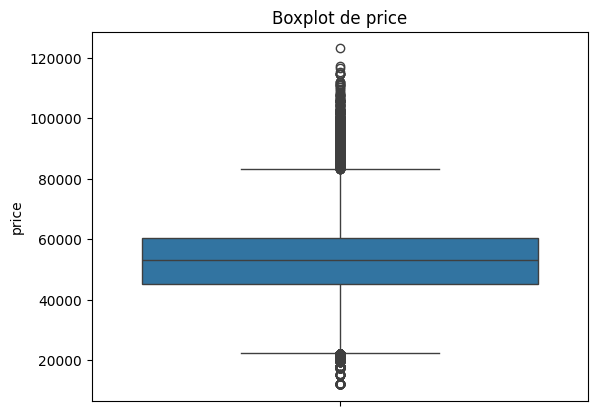

,price,ch_code_2T,ch_code_6E,ch_code_AI,ch_code_G8,ch_code_I5,ch_code_S5,ch_code_SG,ch_code_UK,from_Bangalore,...,bloque_horario_Bloque 7,bloque_horario_Bloque 8,tipo_viaje_Corta distancia,tipo_viaje_Ultra larga distancia,tipo_viaje_larga distancia,tipo_viaje_media distancia,franja_arribo_Alto,franja_arribo_Bajo,franja_arribo_Medio,franja_arribo_Muy Alto
121,95657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
208,85527,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
209,86137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
210,86137,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
211,86776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93401,87051,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
93402,89537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
93403,15000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
93444,87118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
identifica_outliers(df_modelo_business, 'price')

In [ ]:
df_modelo_business = remove_outliers(df_modelo_business, 'price')

##7.2.- Outliers clase Economy

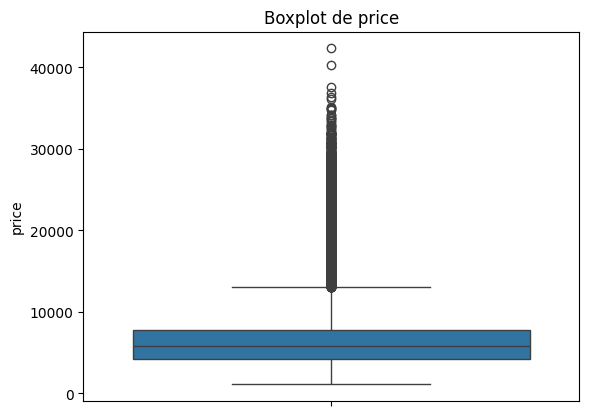

,price,ch_code_2T,ch_code_6E,ch_code_AI,ch_code_G8,ch_code_I5,ch_code_S5,ch_code_SG,ch_code_UK,from_Bangalore,...,bloque_horario_Bloque 7,bloque_horario_Bloque 8,tipo_viaje_Corta distancia,tipo_viaje_Ultra larga distancia,tipo_viaje_larga distancia,tipo_viaje_media distancia,franja_arribo_Alto,franja_arribo_Bajo,franja_arribo_Medio,franja_arribo_Muy Alto
54,13279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
55,13279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
56,13279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
57,13279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
58,13279,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204014,14089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
204015,19580,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
204108,13551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
204109,14076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
identifica_outliers(df_modelo_economic, 'price')

In [ ]:
df_modelo_economic = remove_outliers(df_modelo_economic, 'price')

#8.- Análisis de Correlaciones

Correlación de Pearson entre price y price: 1.00
Correlación de Pearson entre ch_code_2T y price: -0.01
Correlación de Pearson entre ch_code_6E y price: -0.19
Correlación de Pearson entre ch_code_AI y price: 0.10
Correlación de Pearson entre ch_code_G8 y price: -0.06
Correlación de Pearson entre ch_code_I5 y price: -0.24
Correlación de Pearson entre ch_code_S5 y price: -0.01
Correlación de Pearson entre ch_code_SG y price: -0.01
Correlación de Pearson entre ch_code_UK y price: 0.26
Correlación de Pearson entre from_Bangalore y price: 0.01
Correlación de Pearson entre from_Chennai y price: -0.03
Correlación de Pearson entre from_Delhi y price: -0.04
Correlación de Pearson entre from_Hyderabad y price: -0.03
Correlación de Pearson entre from_Kolkata y price: 0.11
Correlación de Pearson entre from_Mumbai y price: -0.02
Correlación de Pearson entre stop_1-stop y price: 0.20
Correlación de Pearson entre stop_2+-stop y price: 0.12
Correlación de Pearson entre stop_non-stop y price: -0.30
Cor

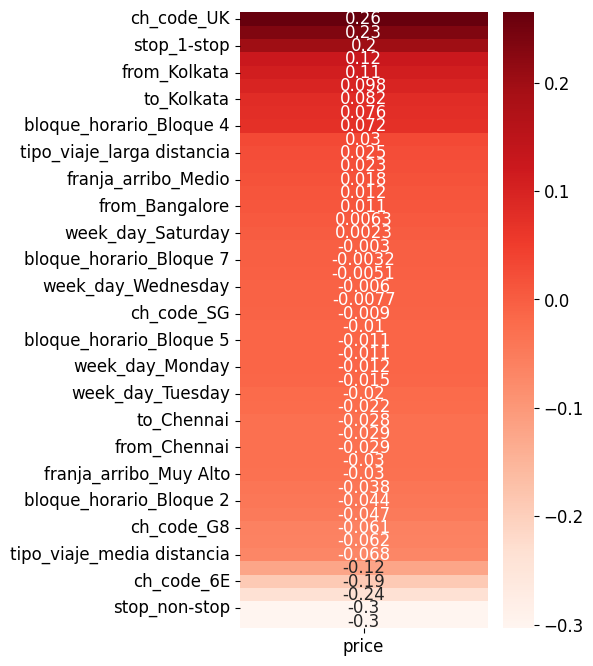

In [ ]:
metric_features, _ = correlacion (df_modelo_economic,'price')

In [ ]:
df_modelo_business = df_modelo_business.drop(columns ={'ch_code_2T','ch_code_6E','ch_code_G8','ch_code_I5','ch_code_S5','ch_code_SG'}, axis=1)

Correlación de Pearson entre price y price: 1.00
Correlación de Pearson entre ch_code_AI y price: -0.30
Correlación de Pearson entre ch_code_UK y price: 0.30
Correlación de Pearson entre from_Bangalore y price: 0.06
Correlación de Pearson entre from_Chennai y price: 0.03
Correlación de Pearson entre from_Delhi y price: -0.17
Correlación de Pearson entre from_Hyderabad y price: -0.07
Correlación de Pearson entre from_Kolkata y price: 0.11
Correlación de Pearson entre from_Mumbai y price: 0.06
Correlación de Pearson entre stop_1-stop y price: 0.44
Correlación de Pearson entre stop_2+-stop y price: 0.13
Correlación de Pearson entre stop_non-stop y price: -0.52
Correlación de Pearson entre to_Bangalore y price: 0.05
Correlación de Pearson entre to_Chennai y price: 0.02
Correlación de Pearson entre to_Delhi y price: -0.19
Correlación de Pearson entre to_Hyderabad y price: -0.08
Correlación de Pearson entre to_Kolkata y price: 0.13
Correlación de Pearson entre to_Mumbai y price: 0.05
Correla

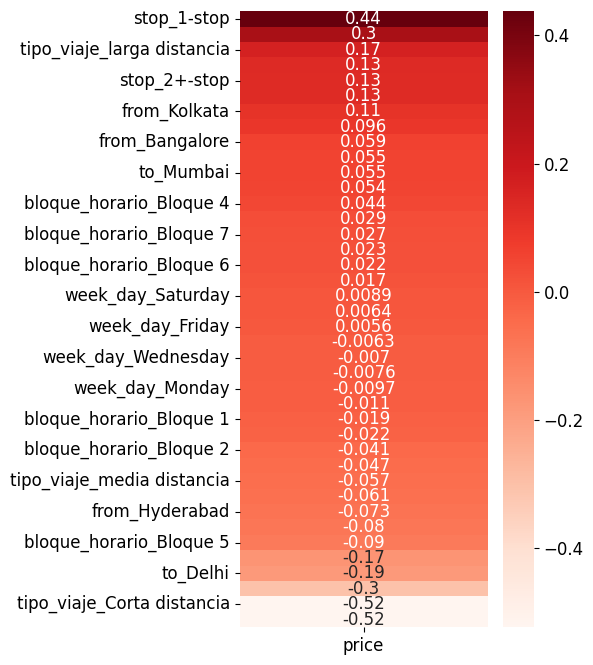

In [ ]:
metric_features, _ = correlacion (df_modelo_business,'price')

#9.- Modelos de regresión para predecir precio del ticket aéreo

##Conjuntos de entrenamiento y test

Clase Business

In [ ]:
X_business = df_modelo_business.drop('price', axis=1)
y_business = np.log(df_modelo_business['price'])

In [ ]:
X_train_business, X_test_business, y_train_business, y_test_business = train_test_split(X_business,y_business, test_size=0.3, random_state=42)

Clase Economic

In [ ]:
X_economic = df_modelo_economic.drop('price', axis=1)
y_economic = np.log(df_modelo_economic['price'])

In [ ]:
X_train_economic, X_test_economic, y_train_economic, y_test_economic = train_test_split(X_economic,y_economic, test_size=0.3, random_state=42)

## Transformación de datos

Clase business

In [ ]:
scaler = StandardScaler()
X_train_business = pd.DataFrame(scaler.fit_transform(X_train_business), columns=X_train_business.columns)
X_test_business = pd.DataFrame(scaler.transform(X_test_business), columns=X_test_business.columns)

Clase Economic

In [ ]:
scaler = StandardScaler()
X_train_economic = pd.DataFrame(scaler.fit_transform(X_train_economic), columns=X_train_economic.columns)
X_test_economic = pd.DataFrame(scaler.transform(X_test_economic), columns=X_test_economic.columns)

##Modelos candidatos para predecir precio del ticket aéreo

In [ ]:
ElasticNet_business = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [ ]:
tree_business = DecisionTreeRegressor(random_state=42)

In [ ]:
RF_business = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
ElasticNet_economic = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [ ]:
tree_economic = DecisionTreeRegressor(random_state=42)

In [ ]:
RF_economic = RandomForestRegressor(n_estimators=100, random_state=42)

###Entrenamiento de modelos Clase business

In [ ]:
ElasticNet_business = ElasticNet_business.fit(X_train_business, y_train_business)

In [ ]:
tree_business = tree_business.fit(X_train_business, y_train_business)

In [ ]:
RF_business = RF_business.fit(X_train_business, y_train_business)

In [ ]:
y_pred_business_ElasticNet = ElasticNet_business.predict(X_test_business)

In [ ]:
y_pred_business_tree = tree_business.predict(X_test_business)

In [ ]:
y_pred_business_RF = RF_business.predict(X_test_business)

### Entrenamiento de modelos Clase economy

In [ ]:
ElasticNet_economic = ElasticNet_economic.fit(X_train_economic, y_train_economic)

In [ ]:
tree_economic = tree_economic.fit(X_train_economic, y_train_economic)

In [ ]:
RF_economic = RF_economic.fit(X_train_economic, y_train_economic)

In [ ]:
y_pred_economic_ElasticNet = ElasticNet_economic.predict(X_test_economic)

In [ ]:
y_pred_economic_tree = tree_economic.predict(X_test_economic)

In [ ]:
y_pred_economic_RF = RF_economic.predict(X_test_economic)

##Métricas para evaluar modelos entrenados

In [ ]:
r2_score(y_test_business,y_pred_business_ElasticNet)

0.35181441469585617

In [ ]:
r2_score(y_test_business,y_pred_business_tree)

0.7660113099955547

In [ ]:
r2_score(y_test_business,y_pred_business_RF)

0.7682401667841643

In [ ]:
np.sqrt(mean_squared_error(y_test_business,y_pred_business_ElasticNet))

np.float64(0.1893906023379955)

In [ ]:
np.sqrt(mean_squared_error(y_test_business,y_pred_business_tree))

np.float64(0.11379054406664477)

In [ ]:
np.sqrt(mean_squared_error(y_test_business,y_pred_business_RF))

np.float64(0.11324729197441305)

##Optimización de parámetros

### Optimización de parámetros y mejor modelo para Clase business

In [ ]:
find_best_model_regression(X_train_business, y_train_business)

Best Model:  ElasticNet(alpha=0.01, l1_ratio=0.2)
Best params:  {'alpha': 0.01, 'l1_ratio': 0.2}
Ajuste:  0.024661760491522487
----------------------------------------------------------------------------------------------------
Best Model:  DecisionTreeRegressor(max_depth=20, min_samples_split=20)
Best params:  {'criterion': 'squared_error', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Ajuste:  0.01319293622821736
----------------------------------------------------------------------------------------------------
Best Model:  RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_split=5,
                      n_estimators=200)
Best params:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Ajuste:  0.012826504089033654
----------------------------------------------------------------------------------------------------


(RandomForestRegressor(),
 {'max_depth': 20,
  'max_features': 'sqrt',
  'min_samples_split': 5,
  'n_estimators': 200},
 [ElasticNet(alpha=0.01, l1_ratio=0.2),
  DecisionTreeRegressor(max_depth=20, min_samples_split=20),
  RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_split=5,
                        n_estimators=200)])

#10.- Conclusiones y recomendaciones


##10.1.- Conclusiones

* El comportamiento de la variable objetivo **precio** es distinto entre las clases **economy** y **business**. Dado lo anterior, se recomienda generar un modelo predictivo para cada una de ellas.

* En el caso de la clase **business** el modelo regresivo con mejor capacidad predictora es el modelo **Random Forest Regressor**. Mientras que en el caso de la clase **economy** el modelo que mejor predice la variable objetivo es el modelo **Decision Tree Regressor**



## 10.2.- Recomendaciones

* Con el fin de mejorar la precisión de los modelos evaluados, se recomienda identificar las variables significativas y ajustar los modelos a ellas.

* Evaluar otos modelos, a modo de ejemplo se menciona el modelo Suppor Vector Machine Regressor (SVR).